In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, json, warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
tf.compat.v1.enable_eager_execution()
from tensorflow import keras
from tensorflow.keras import layers, callbacks, regularizers
from sklearn.metrics import (accuracy_score, roc_auc_score, roc_curve,
                             confusion_matrix, classification_report)

print(f" TensorFlow: {tf.__version__}")

 TensorFlow: 2.19.0


In [7]:
BASE = r"C:\Users\User\Documents\StartupSucessPrediction\outputs\\"

X_train_df = pd.read_csv(BASE + "X_train.csv")
X_test_df  = pd.read_csv(BASE + "X_test.csv")
y_train    = pd.read_csv(BASE + "y_train.csv").squeeze().values
y_test     = pd.read_csv(BASE + "y_test.csv").squeeze().values

X_train = X_train_df.values.reshape(-1, X_train_df.shape[1], 1)
X_test  = X_test_df.values.reshape(-1, X_test_df.shape[1], 1)

print(f"X_train reshaped : {X_train.shape}")
print(f"X_test reshaped  : {X_test.shape}")

X_train reshaped : (763, 42, 1)
X_test reshaped  : (191, 42, 1)


In [8]:
def build_cnn(input_shape):
    model = keras.Sequential([
        layers.Input(shape=input_shape),

        # First conv block — 64 filters, window size 3
        layers.Conv1D(filters=64, kernel_size=3, activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling1D(pool_size=2),
        layers.Dropout(0.3),

        # Second conv block — 128 filters
        layers.Conv1D(filters=128, kernel_size=3, activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling1D(pool_size=2),
        layers.Dropout(0.3),

        # Flatten and classify
        layers.GlobalMaxPooling1D(),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(1, activation='sigmoid')
    ], name="CNN_Model")
    return model

cnn_model = build_cnn((X_train.shape[1], 1))
cnn_model.summary()

Model: "CNN_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                      │ (None, 42, 64)              │             256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 42, 64)              │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d (MaxPooling1D)         │ (None, 21, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 21, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_1 (Conv1D)                    │ (None, 21, 128)             │          24,704 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 21, 128)             │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_1 (MaxPooling1D)       │ (None, 10, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 10, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_max_pooling1d                 │ (None, 128)                 │               0 │
│ (GlobalMaxPooling1D)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 34,049 (133.00 KB)

 Trainable params: 33,665 (131.50 KB)

 Non-trainable params: 384 (1.50 KB)

In [9]:
def build_lstm(input_shape):
    model = keras.Sequential([
        layers.Input(shape=input_shape),

        # First LSTM layer — passes full sequence forward
        layers.LSTM(128, return_sequences=True, dropout=0.3, recurrent_dropout=0.2),
        layers.BatchNormalization(),

        # Second LSTM layer — returns only final state
        layers.LSTM(64, return_sequences=False, dropout=0.2),
        layers.BatchNormalization(),

        layers.Dense(32, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(1, activation='sigmoid')
    ], name="LSTM_Model")
    return model

lstm_model = build_lstm((X_train.shape[1], 1))
lstm_model.summary()

Model: "LSTM_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 42, 128)             │          66,560 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 42, 128)             │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 64)                  │          49,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 118,849 (464.25 KB)

 Trainable params: 118,465 (462.75 KB)

 Non-trainable params: 384 (1.50 KB)

In [10]:
def build_cnn_lstm(input_shape):
    model = keras.Sequential([
        layers.Input(shape=input_shape),

        # CNN part — extract local patterns
        layers.Conv1D(filters=64, kernel_size=3, activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling1D(pool_size=2),
        layers.Dropout(0.3),

        layers.Conv1D(filters=128, kernel_size=3, activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Dropout(0.2),

        # LSTM part — learn from CNN's extracted patterns
        layers.LSTM(64, return_sequences=False, dropout=0.2),
        layers.BatchNormalization(),

        layers.Dense(32, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(1, activation='sigmoid')
    ], name="CNN_LSTM_Hybrid")
    return model

hybrid_model = build_cnn_lstm((X_train.shape[1], 1))
hybrid_model.summary()

Model: "CNN_LSTM_Hybrid"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)                    │ (None, 42, 64)              │             256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 42, 64)              │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_2 (MaxPooling1D)       │ (None, 21, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 21, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_3 (Conv1D)                    │ (None, 21, 128)             │          24,704 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_5                │ (None, 21, 128)             │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 21, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_2 (LSTM)                        │ (None, 64)                  │          49,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_6                │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_6 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 77,505 (302.75 KB)

 Trainable params: 76,993 (300.75 KB)

 Non-trainable params: 512 (2.00 KB)

In [16]:
for m in [cnn_model, lstm_model, hybrid_model]:
    m.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy', keras.metrics.AUC(name='auc')]
    )
print(" All 3 models compiled")

 All 3 models compiled


In [17]:
for name, model in all_models.items():
    print(f"\n Training {name}...")
    hist = model.fit(
        X_train, y_train,
        epochs=100,
        batch_size=32,
        validation_split=0.15,
        callbacks=get_callbacks(name),
        verbose=0
    )
    all_histories[name] = hist

    y_proba = model.predict(X_test)
    y_proba = np.array(y_proba).flatten()   # ← fixes the numpy() error
    y_pred  = (y_proba >= 0.5).astype(int)
    acc     = accuracy_score(y_test, y_pred)
    auc     = roc_auc_score(y_test, y_proba)

    all_results[name] = {"accuracy": acc, "auc": auc,
                         "y_pred": y_pred, "y_proba": y_proba}
    print(f"   {name} → Accuracy: {acc:.4f} | AUC: {auc:.4f} | Epochs: {len(hist.history['loss'])}")

print("\n All 3 deep learning models trained!")


 Training CNN...
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
   CNN → Accuracy: 0.7435 | AUC: 0.8396 | Epochs: 18

 Training LSTM...
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 156ms/step
   LSTM → Accuracy: 0.7173 | AUC: 0.7781 | Epochs: 47

 Training CNN-LSTM...
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 100ms/step
   CNN-LSTM → Accuracy: 0.5236 | AUC: 0.7269 | Epochs: 16

 All 3 deep learning models trained!


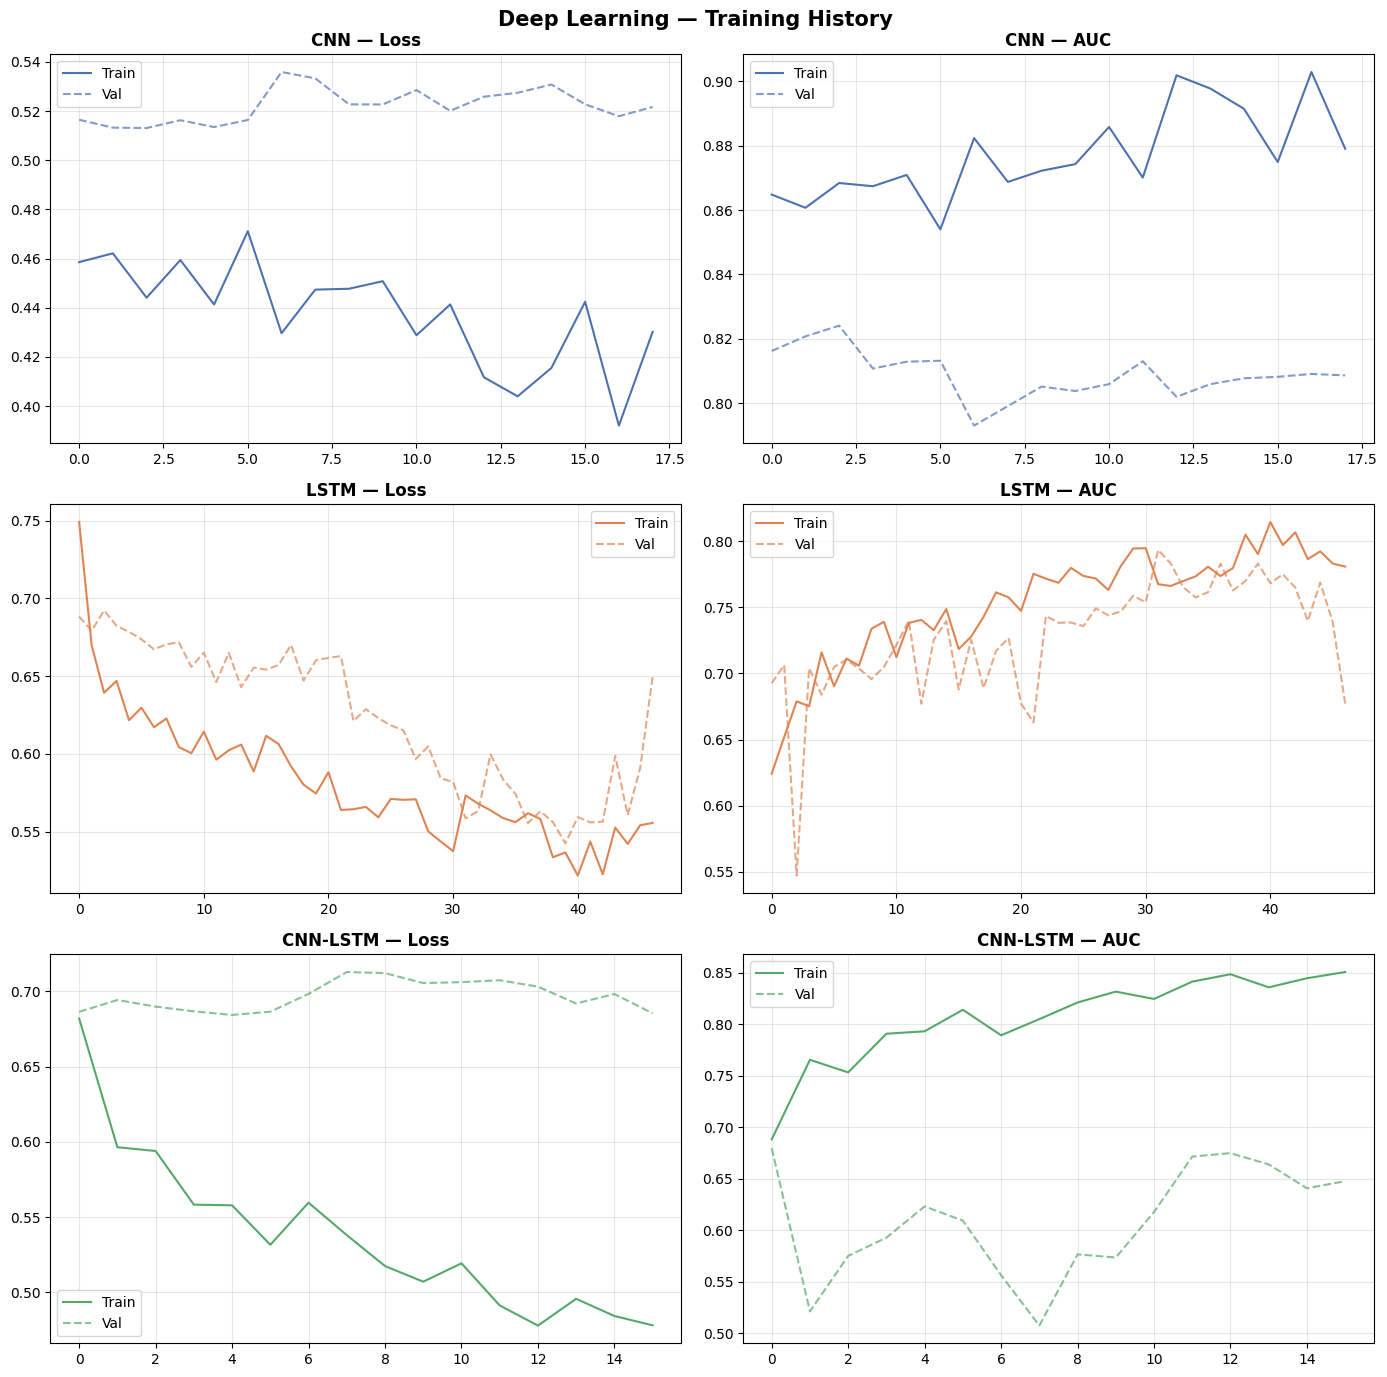

 Saved plot 20


In [18]:
os.makedirs("./outputs/plots", exist_ok=True)

fig, axes = plt.subplots(3, 2, figsize=(14, 14))
fig.suptitle("Deep Learning — Training History", fontsize=15, fontweight='bold')
colors = {"CNN": "#4C72B0", "LSTM": "#DD8452", "CNN-LSTM": "#55A868"}

for i, (name, hist) in enumerate(all_histories.items()):
    # Loss
    axes[i,0].plot(hist.history['loss'],     label='Train', color=colors[name])
    axes[i,0].plot(hist.history['val_loss'], label='Val',   color=colors[name], linestyle='--', alpha=0.7)
    axes[i,0].set_title(f"{name} — Loss", fontweight='bold')
    axes[i,0].legend(); axes[i,0].grid(alpha=0.3)

    # AUC
    axes[i,1].plot(hist.history['auc'],     label='Train', color=colors[name])
    axes[i,1].plot(hist.history['val_auc'], label='Val',   color=colors[name], linestyle='--', alpha=0.7)
    axes[i,1].set_title(f"{name} — AUC", fontweight='bold')
    axes[i,1].legend(); axes[i,1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("./outputs/plots/20_deep_training_history.png", dpi=150)
plt.show()
print(" Saved plot 20")

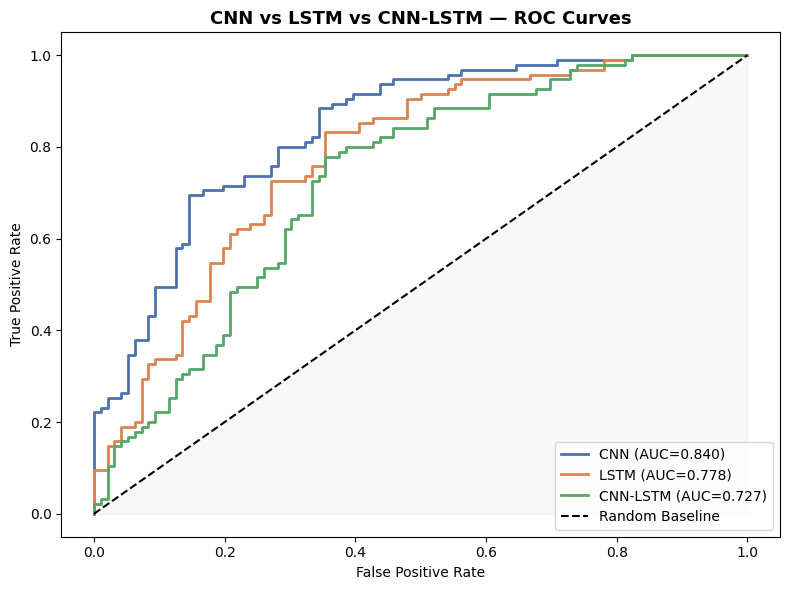

Saved plot 21


In [19]:
fig, ax = plt.subplots(figsize=(8, 6))
colors_list = ["#4C72B0", "#DD8452", "#55A868"]

for (name, res), color in zip(all_results.items(), colors_list):
    fpr, tpr, _ = roc_curve(y_test, res["y_proba"])
    ax.plot(fpr, tpr, lw=2, color=color,
            label=f"{name} (AUC={res['auc']:.3f})")

ax.plot([0,1],[0,1],'k--', label="Random Baseline")
ax.fill_between([0,1],[0,1], alpha=0.05, color='gray')
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("CNN vs LSTM vs CNN-LSTM — ROC Curves", fontsize=13, fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig("./outputs/plots/21_deep_roc_curves.png", dpi=150)
plt.show()
print("Saved plot 21")

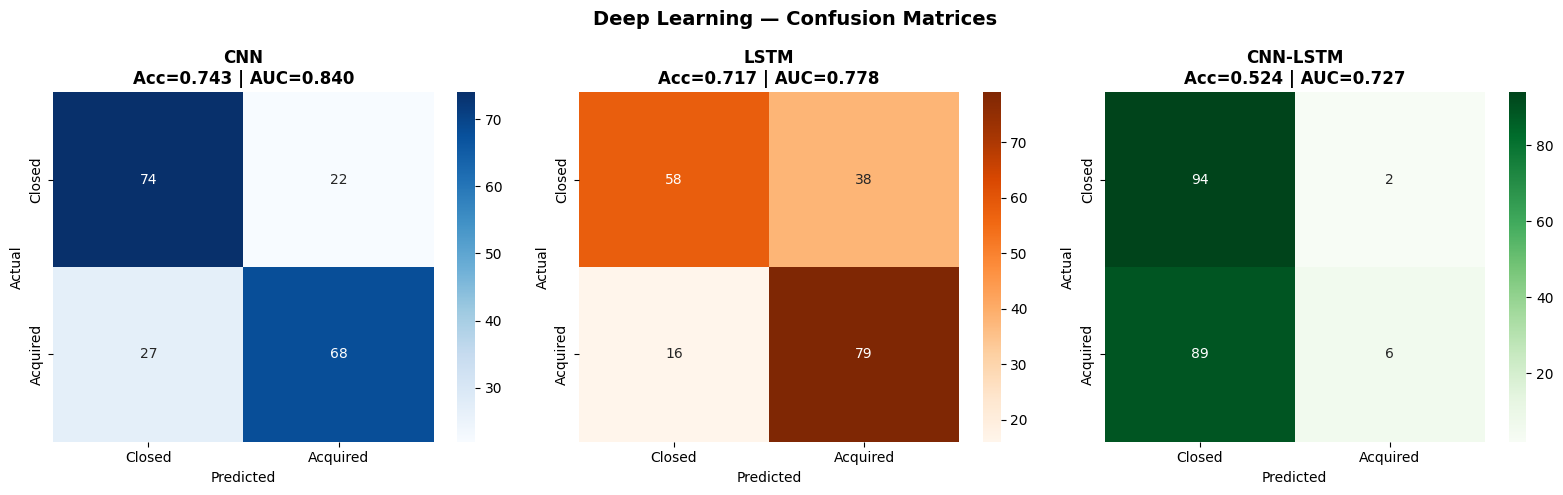

Saved plot 22


In [20]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
cmaps = ["Blues", "Oranges", "Greens"]

for ax, (name, res), cmap in zip(axes, all_results.items(), cmaps):
    cm = confusion_matrix(y_test, res["y_pred"])
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap,
                xticklabels=["Closed","Acquired"],
                yticklabels=["Closed","Acquired"], ax=ax)
    ax.set_title(f"{name}\nAcc={res['accuracy']:.3f} | AUC={res['auc']:.3f}",
                 fontweight='bold')
    ax.set_ylabel("Actual"); ax.set_xlabel("Predicted")

plt.suptitle("Deep Learning — Confusion Matrices", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("./outputs/plots/22_deep_confusion_matrices.png", dpi=150)
plt.show()
print("Saved plot 22")

In [21]:
summary = pd.DataFrame({
    name: {"Accuracy": res["accuracy"], "ROC-AUC": res["auc"]}
    for name, res in all_results.items()
}).T.sort_values("ROC-AUC", ascending=False)

print("=" * 40)
print("  DEEP LEARNING MODEL COMPARISON")
print("=" * 40)
print(summary.to_string())
print("=" * 40)

summary.to_csv("./outputs/deep_learning_comparison.csv")

# Save best deep model name for Module 7
best_deep = summary.index[0]
with open("./outputs/best_deep_model.txt", "w") as f:
    f.write(best_deep)

print(f"\n Best deep learning model: {best_deep}")
print(" Saved to outputs/deep_learning_comparison.csv")

  DEEP LEARNING MODEL COMPARISON
          Accuracy   ROC-AUC
CNN       0.743455  0.839583
LSTM      0.717277  0.778070
CNN-LSTM  0.523560  0.726864

 Best deep learning model: CNN
 Saved to outputs/deep_learning_comparison.csv
